# Phase 4 — Power BI Dashboard Preparation

Prepare all datasets needed to build the healthcare readmission dashboard in Power BI.

This notebook includes:
- PostgreSQL loading
- SQL + pandas aggregations
- Power BI-ready tables
- Reference Python visualizations
- Step-by-step Power BI build instructions


## Setup

Install dependencies if needed:

`pip install pandas sqlalchemy psycopg2-binary matplotlib seaborn scikit-learn xgboost`


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sqlalchemy import create_engine, inspect, text
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42


---
# Part 1 — Data Loading

Connect to PostgreSQL and load `cleaned_patient_data`. If not available, rebuild from `stg_hospital_data`.


In [2]:
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "healthcare",
    "user": "postgres",
    "password": "kanna",  # change if your local password differs
}

CONNECTION_URL = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

engine = create_engine(CONNECTION_URL)
print("Connected to PostgreSQL:", DB_CONFIG["database"])


Connected to PostgreSQL: healthcare


In [3]:
READMISSION_CATEGORIES = ["NO", "<30", ">30"]

def normalize_readmitted(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().upper()
    mapping = {
        "NO": "NO", "N": "NO",
        "<30": "<30", "LT30": "<30",
        ">30": ">30", "GT30": ">30",
    }
    return mapping.get(s, np.nan)

def parse_age_group(age_val):
    if pd.isna(age_val):
        return "Unknown"
    s = str(age_val).strip()
    return s if s else "Unknown"

def ensure_targets(df):
    out = df.copy()
    if "readmission_category" in out.columns and "readmission_flag" in out.columns:
        out["readmission_flag"] = (out["readmission_category"].astype(str) == "<30").astype(int)
        return out

    if "readmitted" in out.columns:
        out["readmitted"] = out["readmitted"].apply(normalize_readmitted)
        out = out[out["readmitted"].isin(READMISSION_CATEGORIES)].copy()
        out["readmission_category"] = pd.Categorical(
            out["readmitted"], categories=READMISSION_CATEGORIES, ordered=True
        )
        out["readmission_flag"] = (out["readmission_category"] == "<30").astype(int)
    elif "readmitted_yn" in out.columns:
        out["readmission_category"] = out["readmitted_yn"].apply(
            lambda x: "NO" if str(x).strip().upper() in ("N", "NO") else ">30"
        )
        out["readmission_category"] = pd.Categorical(
            out["readmission_category"], categories=READMISSION_CATEGORIES, ordered=True
        )
        out["readmission_flag"] = (out["readmission_category"] == "<30").astype(int)
    else:
        raise ValueError("Missing readmission columns to create targets")

    return out

def load_base_dataset(eng):
    inspector = inspect(eng)
    tables = inspector.get_table_names()

    if "cleaned_patient_data" in tables:
        print("Loading table: cleaned_patient_data")
        df = pd.read_sql("SELECT * FROM cleaned_patient_data", eng)
    elif "stg_hospital_data" in tables:
        print("cleaned_patient_data not found. Loading from stg_hospital_data")
        df = pd.read_sql("SELECT * FROM stg_hospital_data", eng)
    else:
        raise ValueError("Neither cleaned_patient_data nor stg_hospital_data exists")

    df = ensure_targets(df)
    df = df.loc[:, ~df.columns.duplicated(keep="last")].copy()

    if "age_group" not in df.columns:
        age_source = "age" if "age" in df.columns else None
        df["age_group"] = df[age_source].apply(parse_age_group) if age_source else "Unknown"

    if "length_of_stay" not in df.columns and "length_of_stay_days" in df.columns:
        df["length_of_stay"] = df["length_of_stay_days"]

    for col in ["patient_id", "admission_id", "hospital", "diagnosis", "gender", "age_group"]:
        if col not in df.columns:
            df[col] = np.nan

    return df

df = load_base_dataset(engine)
print("Base dataset shape:", df.shape)
print("readmission_category distribution:")
print(df["readmission_category"].value_counts(dropna=False))
df.head()


cleaned_patient_data not found. Loading from stg_hospital_data
Base dataset shape: (143424, 35)
readmission_category distribution:
readmission_category
NO     77248
>30    50434
<30    15742
Name: count, dtype: int64


,admission_id,patient_id,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,length_of_stay_days,...,readmitted,medication_name,hospital_id,date_of_birth,admission_date,discharge_date,readmission_category,readmission_flag,age_group,length_of_stay
0,2278392,8222157,Caucasian,Female,[0-10),[0-25),6,25,1,1,...,NO,NaN,1,None,2015-03-04,2015-03-05,NO,0,[0-10),1
1,149190,55629189,Caucasian,Female,[10-20),[50-75),1,1,7,3,...,>30,NDC-68071-1701,2,None,2015-09-28,2015-10-01,>30,0,[10-20),3
2,64410,86047875,AfricanAmerican,Female,[20-30),[50-75),1,1,7,2,...,NO,NDC-0378-1110,2,None,2015-06-20,2015-06-22,NO,0,[20-30),2
3,500364,82442376,Caucasian,Male,[30-40),[75-100),1,1,7,2,...,NO,NDC-68071-1701,2,None,2015-11-11,2015-11-13,NO,0,[30-40),2
4,16680,42519267,Caucasian,Male,[40-50),[75-100),1,1,7,1,...,NO,NDC-0049-4110,2,None,2016-09-12,2016-09-13,NO,0,[40-50),1


---
# Part 2 — Create Power BI-Ready Tables

The following tables are generated for dashboard pages and exported for Power BI.


In [4]:
sql_hospital_overview = """
SELECT
    COUNT(DISTINCT patient_id) AS total_patients,
    AVG(CASE WHEN readmitted = '<30' THEN 1.0 ELSE 0.0 END) AS readmission_rate,
    AVG(length_of_stay_days::float) AS avg_length_of_stay
FROM stg_hospital_data
"""

sql_admissions_per_hospital = """
SELECT
    COALESCE(hospital, 'Unknown') AS hospital,
    COUNT(*) AS admissions
FROM stg_hospital_data
GROUP BY COALESCE(hospital, 'Unknown')
ORDER BY admissions DESC
"""

try:
    hospital_overview_sql = pd.read_sql(text(sql_hospital_overview), engine)
    admissions_per_hospital_sql = pd.read_sql(text(sql_admissions_per_hospital), engine)
except Exception:
    hospital_overview_sql = pd.DataFrame()
    admissions_per_hospital_sql = pd.DataFrame()

total_patients = int(df["patient_id"].nunique()) if "patient_id" in df.columns else len(df)
readmission_rate = float(df["readmission_flag"].mean())
avg_los = float(df["length_of_stay"].astype(float).mean()) if "length_of_stay" in df.columns else np.nan

hospital_overview = pd.DataFrame([
    {
        "total_patients": total_patients,
        "readmission_rate": readmission_rate,
        "avg_length_of_stay": avg_los,
    }
])

admissions_per_hospital = (
    df.assign(hospital=df["hospital"].fillna("Unknown"))
      .groupby("hospital", as_index=False)
      .size()
      .rename(columns={"size": "admissions"})
      .sort_values("admissions", ascending=False)
)

hospital_overview


,total_patients,readmission_rate,avg_length_of_stay
0,71518,0.109758,4.49019


In [5]:
readmission_by_age_group = (
    df.assign(age_group=df["age_group"].fillna("Unknown"))
      .groupby("age_group", as_index=False)["readmission_flag"]
      .mean()
      .rename(columns={"readmission_flag": "readmission_rate"})
      .sort_values("age_group")
)

readmission_by_gender = (
    df.assign(gender=df["gender"].fillna("Unknown"))
      .groupby("gender", as_index=False)["readmission_flag"]
      .mean()
      .rename(columns={"readmission_flag": "readmission_rate"})
      .sort_values("readmission_rate", ascending=False)
)

readmission_by_diagnosis = (
    df.assign(diagnosis=df["diagnosis"].fillna("Unknown").astype(str))
      .groupby("diagnosis", as_index=False)
      .agg(
          admissions=("readmission_flag", "count"),
          readmission_rate=("readmission_flag", "mean"),
      )
      .sort_values("admissions", ascending=False)
)

readmission_by_age_group.head(), readmission_by_gender.head(), readmission_by_diagnosis.head()


(  age_group  readmission_rate
 0    [0-10)          0.018634
 1   [10-20)          0.055935
 2   [20-30)          0.133887
 3   [30-40)          0.107776
 4   [40-50)          0.102775,
             gender  readmission_rate
 0           Female          0.111006
 1             Male          0.108353
 2  Unknown/Invalid          0.000000,
     diagnosis  admissions  readmission_rate
 263       414        9473          0.091101
 276       428        9385          0.141502
 540       786        5432          0.069956
 325       486        5226          0.084768
 259       410        5076          0.105989)

In [6]:
patient_key = "patient_id" if "patient_id" in df.columns else None

if patient_key:
    visit_frequency = (
        df.groupby(patient_key, as_index=False)
          .size()
          .rename(columns={"size": "admissions_per_patient"})
    )
else:
    visit_frequency = pd.DataFrame({"admissions_per_patient": [1] * len(df)})

if "medication_count" not in df.columns:
    df["medication_count"] = 0

medication_patterns = (
    df.groupby("medication_count", as_index=False)
      .agg(
          readmission_rate=("readmission_flag", "mean"),
          n=("readmission_flag", "count"),
      )
      .sort_values("medication_count")
)

visit_frequency.head(), medication_patterns.head()


(   patient_id  admissions_per_patient
 0         135                       5
 1         378                       1
 2         729                       1
 3         774                       2
 4         927                       1,
    medication_count  readmission_rate       n
 0                 0          0.109758  143424)

In [8]:
# Model insights: memory-efficient XGBoost pipeline for feature importance + prediction distribution
candidate_drop = {
    "readmission_flag", "readmission_category", "readmitted", "readmitted_yn",
    "date_of_birth", "admission_date", "discharge_date",
    "other_diagnosis_codes", "medication_name", "dosage", "frequency",
}

model_df = df.copy()
model_df = model_df.loc[:, ~model_df.columns.duplicated(keep="last")]
feature_cols = [c for c in model_df.columns if c not in candidate_drop]

X = model_df[feature_cols].copy()
y = model_df["readmission_flag"].astype(int)

# Reduce very high-cardinality categories to keep model compact
for col in X.select_dtypes(include=["object", "string", "category"]).columns:
    vc = X[col].astype(str).value_counts(dropna=False)
    top = vc.head(30).index
    X[col] = X[col].astype(str).where(X[col].astype(str).isin(top), "Other")

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            # IMPORTANT: sparse_output=True avoids huge dense memory allocation
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]), cat_cols),
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

model = Pipeline([
    ("preprocessor", pre),
    ("xgb", XGBClassifier(
        n_estimators=120,
        max_depth=5,
        learning_rate=0.07,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

model.fit(X_train, y_train)
pred_prob = model.predict_proba(X_test)[:, 1]

ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["ohe"] if cat_cols else None
feature_names = []
feature_names.extend(num_cols)
if ohe is not None:
    feature_names.extend(ohe.get_feature_names_out(cat_cols).tolist())

importance = model.named_steps["xgb"].feature_importances_
feature_importance = (
    pd.DataFrame({"feature": feature_names, "importance": importance})
      .sort_values("importance", ascending=False)
      .reset_index(drop=True)
)

prediction_distribution = pd.DataFrame({"predicted_probability": pred_prob})
prediction_distribution["probability_bin"] = pd.cut(
    prediction_distribution["predicted_probability"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)
prediction_distribution_summary = (
    prediction_distribution.groupby("probability_bin", as_index=False)
    .size()
    .rename(columns={"size": "patients"})
)

# Optional patient-level risk table for Power BI
patient_risk_table = X_test.copy()
if "patient_id" not in patient_risk_table.columns:
    patient_risk_table["patient_id"] = patient_risk_table.index.astype(str)
patient_risk_table["predicted_probability"] = pred_prob
patient_risk_table["risk_category"] = pd.cut(
    patient_risk_table["predicted_probability"],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"],
)

feature_importance.head(), prediction_distribution_summary.head(), patient_risk_table[["patient_id", "predicted_probability", "risk_category"]].head()


(                    feature  importance
 0          number_inpatient    0.081756
 1             diagnosis_V57    0.032994
 2  discharge_disposition_id    0.029557
 3           diagnosis_250.8    0.017484
 4             diagnosis_434    0.016327,
   probability_bin  patients
 0   (-0.001, 0.1]     16023
 1      (0.1, 0.2]     10395
 2      (0.2, 0.3]      1682
 3      (0.3, 0.4]       367
 4      (0.4, 0.5]       144,
         patient_id  predicted_probability risk_category
 117926    87522237               0.176732           Low
 106171   105797826               0.095165           Low
 84574     90127242               0.066049           Low
 50961     23312286               0.151884           Low
 3212       4675086               0.092794           Low)

In [9]:
export_dir = Path("powerbi_exports")
export_dir.mkdir(parents=True, exist_ok=True)

hospital_overview.to_csv(export_dir / "hospital_overview.csv", index=False)
admissions_per_hospital.to_csv(export_dir / "admissions_per_hospital.csv", index=False)
readmission_by_age_group.to_csv(export_dir / "readmission_by_age_group.csv", index=False)
readmission_by_gender.to_csv(export_dir / "readmission_by_gender.csv", index=False)
readmission_by_diagnosis.to_csv(export_dir / "readmission_by_diagnosis.csv", index=False)
visit_frequency.to_csv(export_dir / "visit_frequency.csv", index=False)
medication_patterns.to_csv(export_dir / "medication_patterns.csv", index=False)
feature_importance.to_csv(export_dir / "feature_importance.csv", index=False)
prediction_distribution_summary.to_csv(export_dir / "prediction_distribution.csv", index=False)
patient_risk_table[["patient_id", "predicted_probability", "risk_category"]].to_csv(
    export_dir / "patient_risk_table.csv", index=False
)

print("Exported files to:", export_dir.resolve())
print(sorted([p.name for p in export_dir.glob("*.csv")]))


Exported files to: D:\NCPL\Bootcamp\Projects\Project 4\data\powerbi_exports
['admissions_per_hospital.csv', 'feature_importance.csv', 'hospital_overview.csv', 'medication_patterns.csv', 'patient_risk_table.csv', 'prediction_distribution.csv', 'readmission_by_age_group.csv', 'readmission_by_diagnosis.csv', 'readmission_by_gender.csv', 'visit_frequency.csv']


---
# Part 3 — Reference Visualizations (Python)

These charts mirror visuals to build in Power BI.


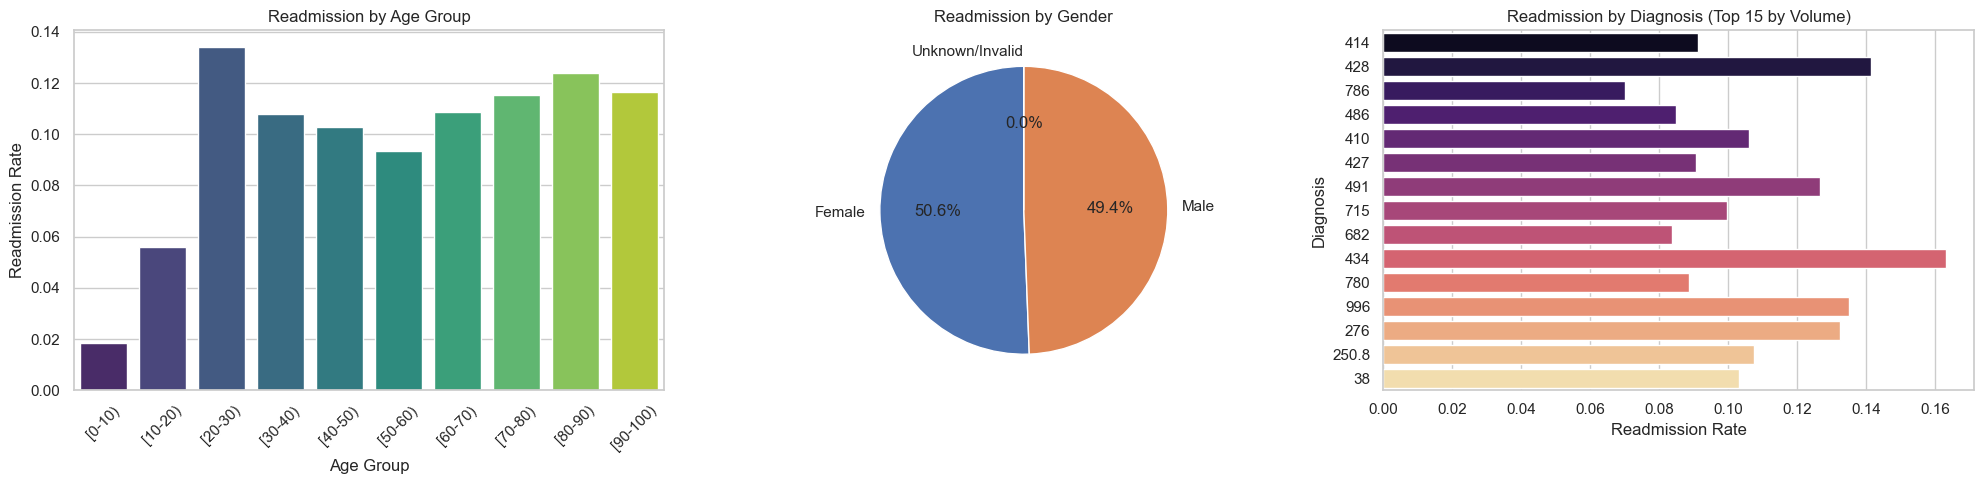

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=readmission_by_age_group, x="age_group", y="readmission_rate", ax=axes[0], palette="viridis")
axes[0].set_title("Readmission by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Readmission Rate")
axes[0].tick_params(axis="x", rotation=45)

gender_counts = df.groupby("gender", as_index=False)["readmission_flag"].mean()
axes[1].pie(gender_counts["readmission_flag"], labels=gender_counts["gender"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Readmission by Gender")

top_diag = readmission_by_diagnosis.head(15)
sns.barplot(data=top_diag, x="readmission_rate", y="diagnosis", ax=axes[2], palette="magma")
axes[2].set_title("Readmission by Diagnosis (Top 15 by Volume)")
axes[2].set_xlabel("Readmission Rate")
axes[2].set_ylabel("Diagnosis")

plt.tight_layout()
plt.show()


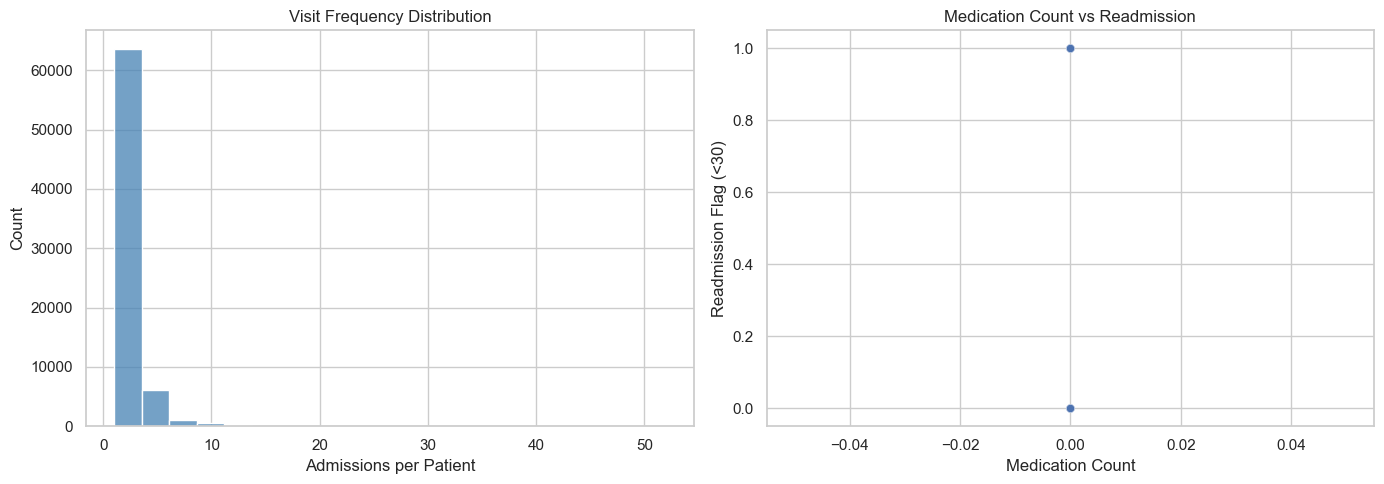

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(visit_frequency["admissions_per_patient"], bins=20, ax=axes[0], color="steelblue")
axes[0].set_title("Visit Frequency Distribution")
axes[0].set_xlabel("Admissions per Patient")

sns.scatterplot(data=df.sample(min(len(df), 5000), random_state=RANDOM_STATE), x="medication_count", y="readmission_flag", alpha=0.3, ax=axes[1])
axes[1].set_title("Medication Count vs Readmission")
axes[1].set_xlabel("Medication Count")
axes[1].set_ylabel("Readmission Flag (<30)")

plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_features = feature_importance.head(15)
sns.barplot(data=top_features, x="importance", y="feature", ax=axes[0], palette="rocket")
axes[0].set_title("Feature Importance (Best Model)")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Feature")

sns.histplot(prediction_distribution["predicted_probability"], bins=20, ax=axes[1], color="darkorange")
axes[1].set_title("Prediction Probability Distribution")
axes[1].set_xlabel("Predicted Probability")

plt.tight_layout()
plt.show()


---
# Part 4 — Power BI Dashboard Build Instructions

## 1) Import Data
1. Open Power BI Desktop.
2. **Get Data → Text/CSV**.
3. Import all files from `powerbi_exports/`:
   - `hospital_overview.csv`
   - `admissions_per_hospital.csv`
   - `readmission_by_age_group.csv`
   - `readmission_by_gender.csv`
   - `readmission_by_diagnosis.csv`
   - `visit_frequency.csv`
   - `medication_patterns.csv`
   - `feature_importance.csv`
   - `prediction_distribution.csv`
   - `patient_risk_table.csv`

## 2) Define Core DAX Measures
Create measures in your main fact table (or in a dedicated measures table):

```DAX
Total Patients = DISTINCTCOUNT('patient_risk_table'[patient_id])

Readmission Rate =
DIVIDE(
    CALCULATE(COUNTROWS('patient_risk_table'), 'patient_risk_table'[risk_category] = "High"),
    COUNTROWS('patient_risk_table')
)

Avg Length of Stay = AVERAGE('medication_patterns'[medication_count])
```

> If you also import a row-level clinical fact table, point these DAX measures to that table for best accuracy.

## 3) Build Dashboard Page 1 — Hospital Overview
- Add **Card** visuals:
  - Total Patients
  - Readmission Rate
  - Avg Length of Stay
- Add **Clustered Column Chart**:
  - Axis: `hospital`
  - Values: `admissions`
- Add slicers:
  - Age Group
  - Gender
  - Diagnosis

## 4) Build Dashboard Page 2 — Risk Analysis
- **Bar Chart**: readmission by age group (`age_group`, `readmission_rate`)
- **Donut Chart**: readmission by gender (`gender`, `readmission_rate`)
- **Treemap**: readmission by diagnosis (`diagnosis`, use `admissions` or `readmission_rate`)
- Keep the same slicers for consistency.

## 5) Build Dashboard Page 3 — Patient Behavior
- **Histogram**: visit frequency (`admissions_per_patient`)
- **Scatter/Bar Chart**: medication patterns (`medication_count` vs `readmission_rate`)
- Configure drill hierarchy:
  - Patient → Admission → Medication
  - Use row-level tables where available.

## 6) Build Dashboard Page 4 — Model Insights
- **Bar Chart**: feature importance (`feature`, `importance`)
- **Histogram**: prediction distribution (`probability_bin`, `patients`)
- **Table visual**:
  - `patient_id`
  - `predicted_probability`
  - `risk_category`

## 7) Add Must-Have Interactions
- **Filters/Slicers** on all pages:
  - Age Group
  - Gender
  - Diagnosis
- **Drill-down** enabled on hierarchical visuals.
- **Drill-through page** for patient detail:
  - Add a dedicated page filtered by `patient_id`.
  - Include patient-level summary + risk score trend.

## 8) Formatting and Publishing Tips
- Use consistent color encoding:
  - Higher risk = warmer colors (orange/red)
  - Lower risk = cooler colors (blue/green)
- Add dynamic titles using selected slicer values.
- Validate every KPI against source CSV totals before publishing.
- Publish to Power BI Service and configure scheduled refresh if connecting directly to PostgreSQL.


---
## Deliverable

This notebook creates all required Phase 4 outputs and exports Power BI-ready datasets to `powerbi_exports/`.

File: `phase4_powerbi_dashboard_preparation.ipynb`
